<a href="https://colab.research.google.com/github/danielesivori/ROSE-PhD-Course-SHM-in-EE-2026/blob/main/Tutorial_1_AV/Tutorial_1_AV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**TUTORIAL 1** - Output-only modal identification from ambient vibrations

## Introduction

We analyse **ambient vibration**  recordings acquired from a permanent dynamic monitoring system on a 2-storey masonry building. The structure has been damaged during the 2016 Central Italy earthquake sequence, reaching a moderate global damage level (DS2).

We will identify the natural frequencies of the building, the associated mode shapes and damping ratios in pristine conditions (**Tutorial 1**) and then analyze the building response to the earthquake (**Tutorial 2**).

To perform modal identification we will focus on a simple but effective output-only frequency-domain modal identification technique, the Frequency Domain Decomposition (FDD).

## Building \& data description (metadata)

The operational response of the structure has been recorded by two bi-axial FB accelerometers placed at each floor (L1, L2) whose channels are oriented along the two main directions of the building (X, Y). The sensors are also aligned vertically along the height of the building and placed roughly in its geometric center. Being the building symmetric in plan, this configuration can reliably capture horizontal translations but not torsion. The length of the recording is 30 min and the sampling rate is 250Hz.

Accelerations are reported in units of gravity (g), with samples organized in rows and channels in columns according to the following scheme:

COL1 COL2 COL3 COL4


L1_X L1_Y L2_X L2_Y

## Data loading

Lets start by loading the data, which is saved in a text file on a public GitHub repository (https://github.com/danielesivori/ROSE-PhD-Course-SHM-in-EE-2026).

In [1]:
import pandas as pd

# Construct the raw GitHub URL for the data file based on the user's provided link
data_url = 'https://raw.githubusercontent.com/danielesivori/ROSE-PhD-Course-SHM-in-EE-2026/main/Tutorial_1_AV/Tutorial_1_AV_data.txt'

# Load the data using pandas.read_csv, specifying space as a separator and no header
df = pd.read_csv(data_url, sep=r'\s+', header=None)
#df = pd.read_csv('Tutorial_1_AV_data.txt', sep=r'\s+', header=None)

# Display the first few rows of the dataframe
print("Data loaded")
print(df.head())

Data loaded
          0         1         2         3
0  0.000008 -0.000039  0.000038  0.000003
1  0.000024 -0.000031  0.000036  0.000015
2  0.000018  0.000007  0.000049  0.000031
3  0.000025 -0.000005  0.000046  0.000014
4 -0.000003 -0.000020  0.000021 -0.000008


The loaded data consists of 4 signals (columns) sampled over time. Let's visualize these signals to understand their time-domain behavior.

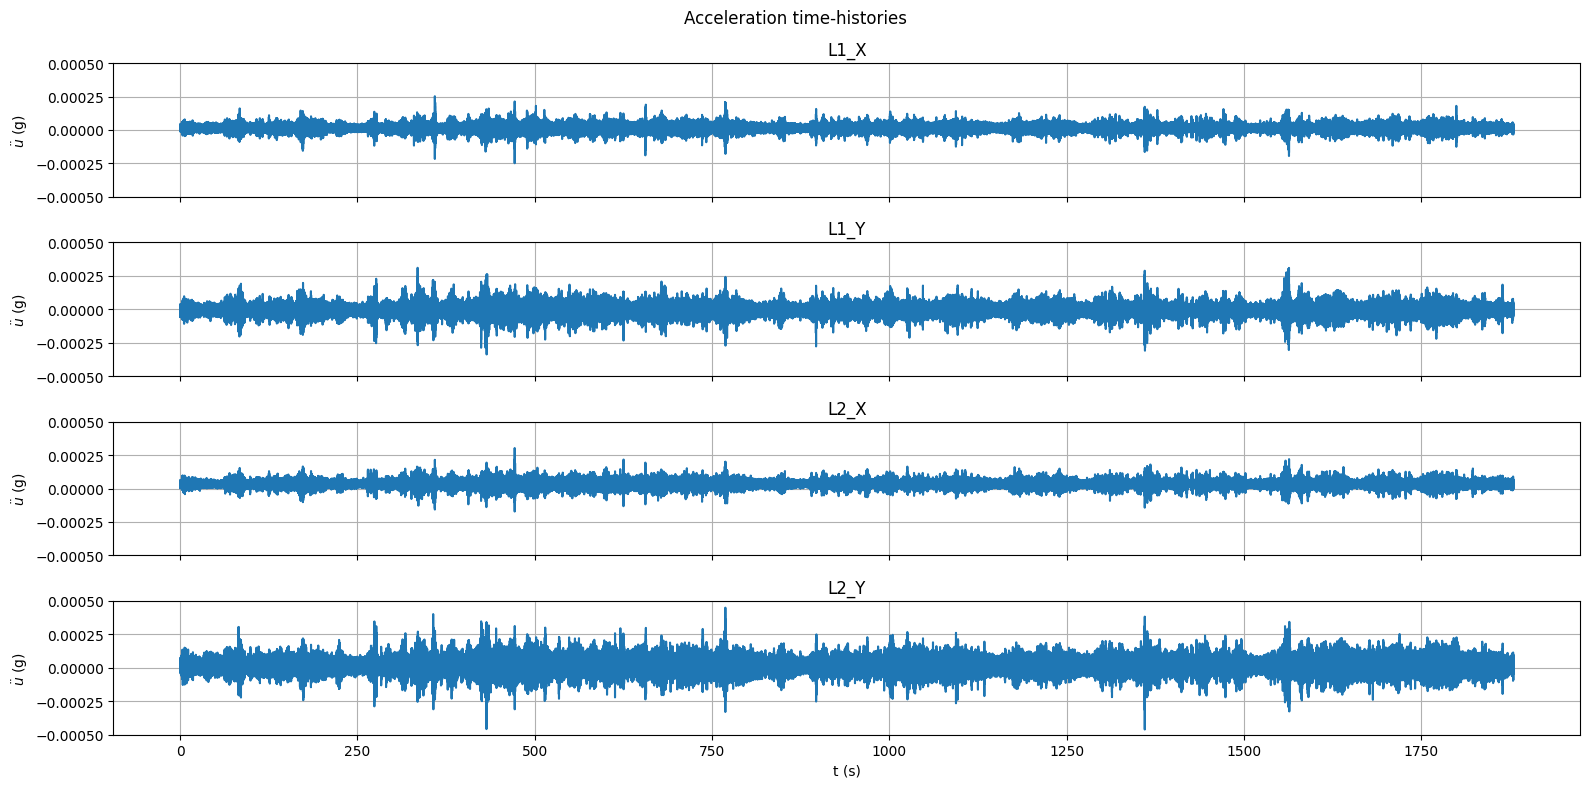

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# To numpy array
data = df.to_numpy()
data

fs = 250 # sampling frequency in Hz
Ts = 1/fs # sampling period in s
n = data.shape[0] # number of samples
N = data.shape[1] # number of channels
t = n / fs # length in seconds

# Time vector
time_v = np.arange(n) / fs

# Define channel names as per the problem description
channel_names = ['L1_X', 'L1_Y', 'L2_X', 'L2_Y']

# Create a figure with subplots for each signal
fig, axes = plt.subplots(nrows=N, ncols=1, figsize=(16, 8), sharex=True)

# Plot each signal in its own subplot
for i in range(N):
    axes[i].plot(time_v, data[:, i], label=channel_names[i])
    axes[i].set_title(f'{channel_names[i]}')
    axes[i].set_ylabel(r'$\ddot{u}$ (g)')
    axes[i].grid(True)
    # axes[i].legend(loc='upper right')
    axes[i].set_ylim(-0.0005,0.0005)

# Set a common x-axis label for the bottom subplot
axes[-1].set_xlabel('t (s)')

plt.suptitle('Acceleration time-histories')
plt.tight_layout()
plt.show()

## Pre-processing - decimation & filtering

We perform an initial estimate of the **Power Spectral Density (PSD)** of the signals using the Welch's method to take a look at the frequency content and plan filtering and decimation before proceeding with the identification.

Using 18 overlapping segments of length 100s (25000 samples) for an approximate frequency resolution of 0.01 Hz


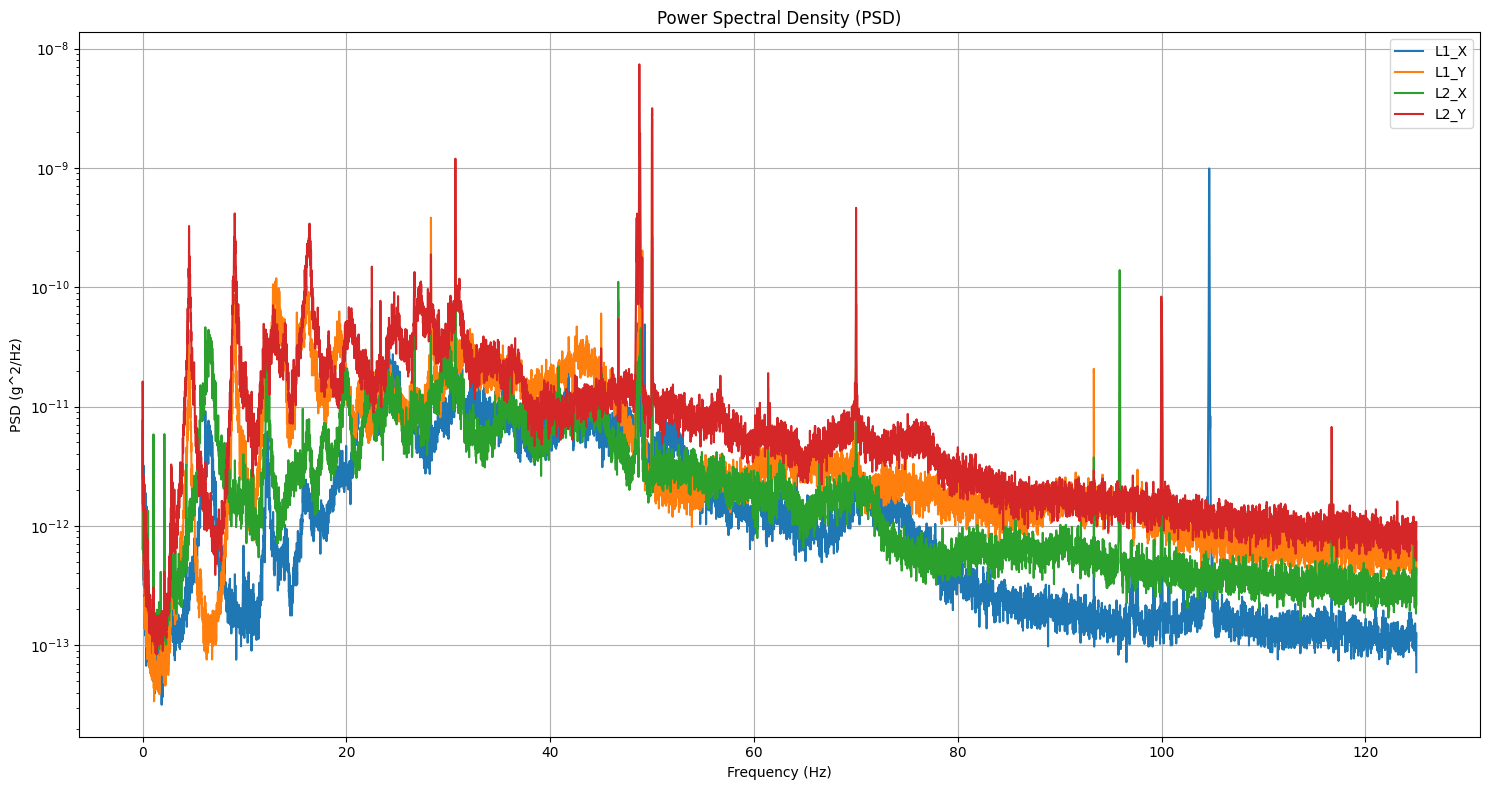

In [3]:
from scipy.signal import welch

# Parameters for Welch's method
# Fix the frequency resolution (delta_f)
delta_f = 0.01 # Hz

# Calculate length of each segment based on desired frequency resolution and sampling rate
# nperseg = seg_length * fs = (1 / delta_f) * fs
seg_len = (1 / delta_f)
nperseg = seg_len * fs

# How many segments (averages)?
nseg = n // nperseg

print(f"Using {nseg:.0f} overlapping segments of length {seg_len:.0f}s ({nperseg:.0f} samples) for an approximate frequency resolution of {1/seg_len:.2f} Hz")

# Single figure for all PSDs
plt.figure(figsize=(15, 8))

# Plot PSD for each channel
for i in range(N):

    # Welch's method with classic Hanning window
    fv, Pxx = welch(data[:, i], fs=fs, nperseg=nperseg, noverlap=nperseg//2, window='hann', scaling='density')

    # Plot
    plt.semilogy(fv, Pxx, label=channel_names[i]) # semilogy

plt.title('Power Spectral Density (PSD)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('PSD (g^2/Hz)')
plt.grid(True)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

### Decimation

There are several amplification peaks in the range [0.5-20] Hz. Let's start by **decimating** the data by fixing the new Nyquist frequency to 25 Hz. Typically decimation function applies an **anti-aliasing low-pass filter** (Chebyshev type I in this case) before downsampling.

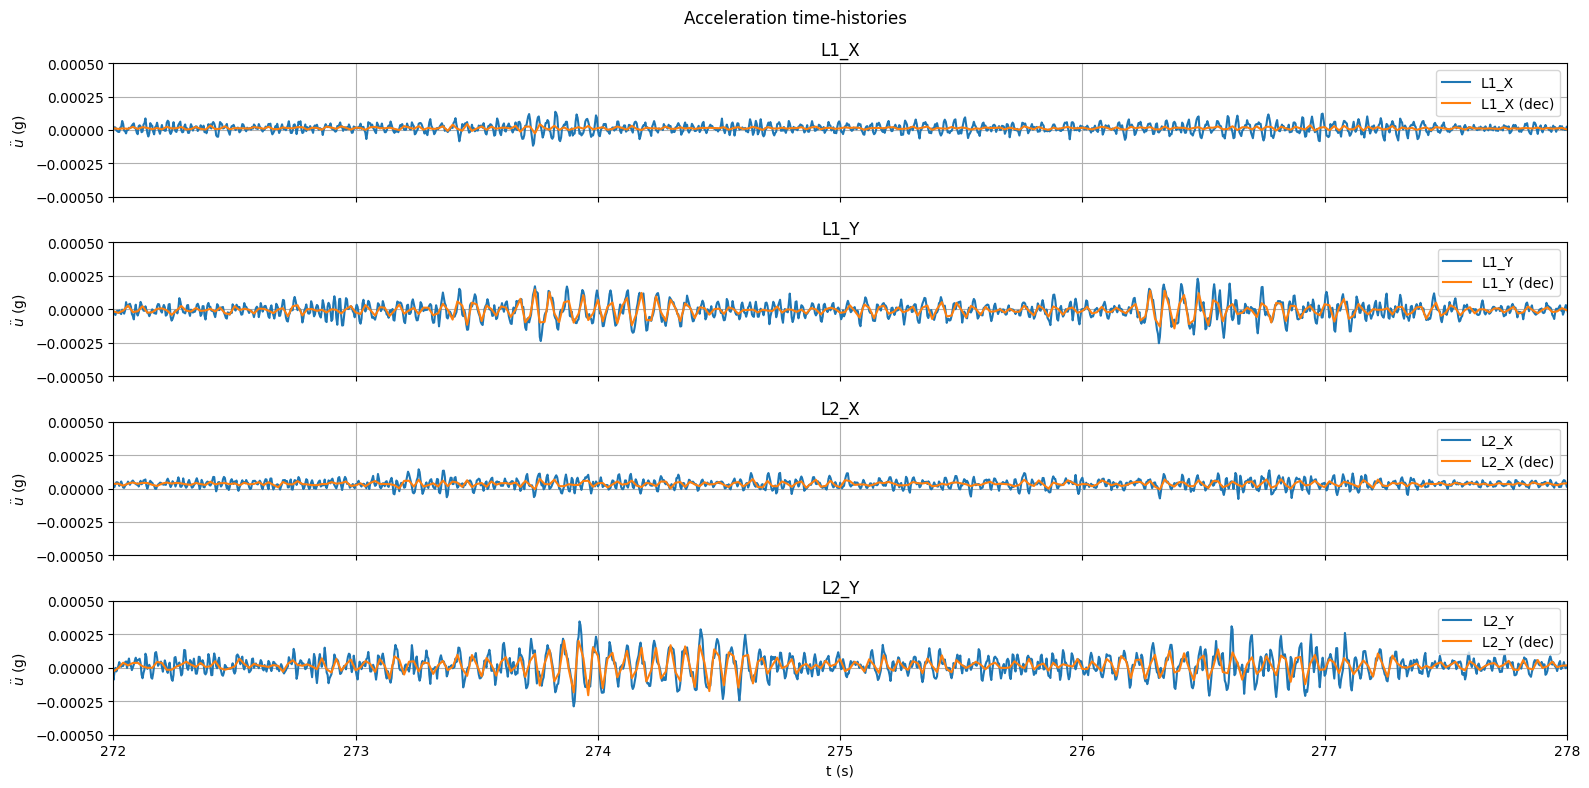

In [4]:
from scipy.signal import decimate

f_nyq_dec = 25 # desired Nyquist frequency after decimation (must be < fs/2)
dec_factor = fs // (2 * f_nyq_dec)  # decimation factor: 250 / (2*25) = 5
fs_dec = fs // dec_factor  # 50 Hz

# Decimate each channel (applies anti-aliasing filter internally)
data_dec = np.column_stack([decimate(data[:, i], dec_factor) for i in range(N)])

n_dec = data_dec.shape[0]
time_v_dec = np.arange(n_dec) / fs_dec

# Create a figure with subplots for each signal
fig, axes = plt.subplots(nrows=N, ncols=1, figsize=(16, 8), sharex=True)

# Plot each signal in its own subplot
for i in range(N):
    axes[i].plot(time_v, data[:, i], label=channel_names[i])
    axes[i].plot(time_v_dec, data_dec[:, i], label=f'{channel_names[i]} (dec)')
    axes[i].set_title(f'{channel_names[i]}')
    axes[i].set_ylabel(r'$\ddot{u}$ (g)')
    axes[i].grid(True)
    axes[i].legend(loc='upper right')
    axes[i].set_ylim(-0.0005,0.0005)
    axes[i].set_xlim(272,278)

# Set a common x-axis label for the bottom subplot
axes[-1].set_xlabel('t (s)')

plt.suptitle('Acceleration time-histories')
plt.tight_layout()
plt.show()

We estimate the PSD again on the decimated signal:

Using 18 overlapping segments of length 100s (25000 samples) for an approximate frequency resolution of 0.01 Hz


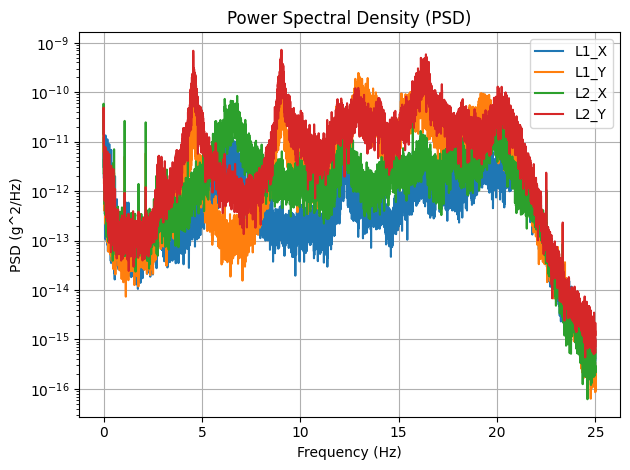

In [5]:
# Calculate length of each segment based on desired frequency resolution and sampling rate
# nperseg = seg_length * fs = (1 / delta_f) * fs
seg_len = (1 / delta_f)
nperseg = seg_len * fs

# How many segments (averages)?
nseg = n // nperseg

print(f"Using {nseg:.0f} overlapping segments of length {seg_len:.0f}s ({nperseg:.0f} samples) for an approximate frequency resolution of {1/seg_len:.2f} Hz")

# Plot PSD for each channel
for i in range(N):

    # Welch's method with classic Hanning window
    fv, Pxx = welch(data_dec[:, i], fs=fs_dec, nperseg=nperseg, noverlap=nperseg//2, window='hann', scaling='density')

    # Plot
    plt.semilogy(fv, Pxx, label=channel_names[i]) # semilogy

plt.title('Power Spectral Density (PSD)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('PSD (g^2/Hz)')
plt.grid(True)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

### Filtering

There is some unwanted low frequency content below the first amplification at 5 Hz. Let's apply a **high-pass filter** at 2 Hz (acausal, FIR or IIR). This will also remove potential **trends and offset** from zero-mean (DC component).

We can choose an **IIR Butterworth filter** (rather than FIR) for computational efficiency
and robustness. The zero-phase sosfiltfilt application ensures acausality (forward-backward
filtering), eliminating the phase distortion that would occur with a standard causal filter.

High-pass IIR Butterworth filter. Order: 6, cutoff: 2.0 Hz, fs: 50 Hz


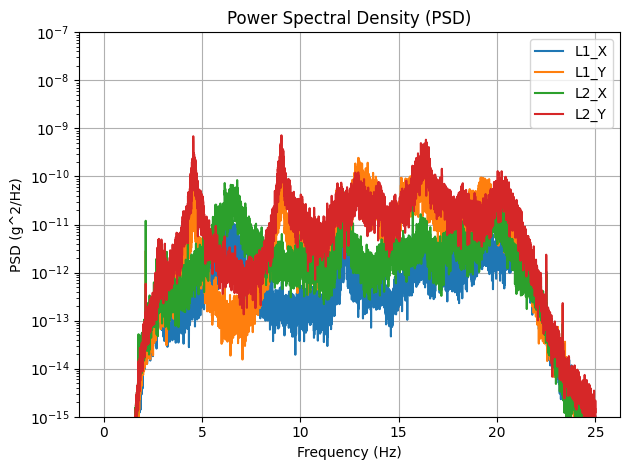

In [6]:
from scipy.signal import butter, sosfiltfilt

f_cutoff = 2.0     # Hz

# # FIR
# numtaps  = 501 # filter order + 1 (odd → symmetric, linear phase)
# # firwin designs low-pass by default; pass_zero=False → high-pass
# b = firwin(numtaps, f_cutoff, fs=fs_dec, pass_zero=False, window='hamming')
# # filtfilt: zero-phase forward-backward application (acausal)
# data_filt = np.column_stack([filtfilt(b, 1.0, data_dec[:, i]) for i in range(N)])
# print(f"High-pass FIR filter. Order: {numtaps - 1}, cutoff: {f_cutoff} Hz, fs: {fs_dec} Hz")

# IIR
order = 6 # same order of decimate
# sos: second-order sections
sos = butter(order, f_cutoff, btype='high', fs=fs_dec, output='sos')
# sosfiltfilt: zero-phase forward-backward application (acausal)
data_filt = np.column_stack([sosfiltfilt(sos, data_dec[:, i]) for i in range(N)])

print(f"High-pass IIR Butterworth filter. Order: {order}, cutoff: {f_cutoff} Hz, fs: {fs_dec} Hz")

# Plot PSD for each channel
for i in range(N):

    # Welch's method with classic Hanning window
    fv, Pxx = welch(data_filt[:, i], fs=fs_dec, nperseg=nperseg, noverlap=nperseg//2, window='hann', scaling='density')

    # Plot
    plt.semilogy(fv, Pxx, label=channel_names[i]) # semilogy

plt.title('Power Spectral Density (PSD)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('PSD (g^2/Hz)')
plt.ylim(10e-16,10e-8)
plt.grid(True)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()


## Output-only modal identification by Frequency Domain Decomposition (FDD)

We can now proceed with an **output-only** modal identification technique in the frequency domain, the **Frequency Domain Decomposition (FDD)**:
- we compute the cross-power spectral density matrix (CPSD);
- based on the resolution we selected, at each discrete frequency, we decompose CPSD by using SVD such that CPSD = USV^T
- we extract the singular values from S and select potential modal candidates from the peaks of the first SV, according to collinearity criteria (see next cell)
- we extract the first singular vector from the first column of U, which contains mode shapes (at the frequencies selected for SV)

See: Brincker, R., Zhang, L., & Andersen, P. (2001). Modal identification of output-only systems using frequency domain decomposition. Smart materials and structures, 10(3), 441-445. https://doi.org/10.1088/0964-1726/10/3/303

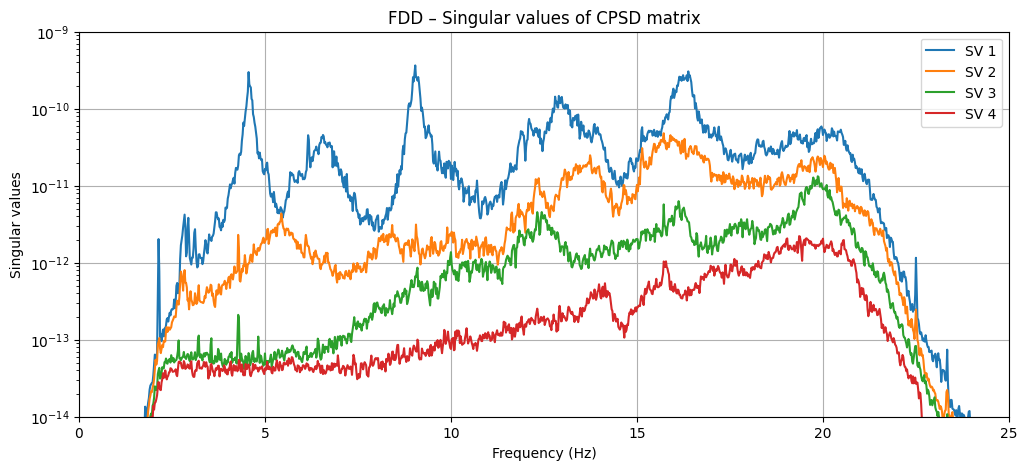

In [7]:
from scipy.signal import csd

# Welch parameters
delta_f = 0.02  # Hz — frequency resolution
nperseg = int(fs_dec / delta_f)

# Cross-PSD matrix G [N x N x nf]
fv, _ = csd(data_filt[:, 0], data_filt[:, 0], fs=fs_dec,
            nperseg=nperseg, noverlap=nperseg//2, window='hann')
nf = len(fv)

G = np.zeros((N, N, nf), dtype=complex)
for i in range(N):
    for j in range(N):
        _, G[i, j, :] = csd(data_filt[:, i], data_filt[:, j], fs=fs_dec,
                             nperseg=nperseg, noverlap=nperseg//2, window='hann')

# SVD at each frequency line
S_all = np.zeros((N, nf))         # all singular values  [N x nf]
U1    = np.zeros((N, nf), dtype=complex)  # first singular vector (complex) [N x nf]

for k in range(nf):
    U, S, _ = np.linalg.svd(G[:, :, k])
    S_all[:, k] = S
    U1[:, k]    = U[:, 0]

# Plot all singular values
plt.figure(figsize=(12, 5))
for i in range(N):
    plt.semilogy(fv, S_all[i, :], label=f'SV {i+1}')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Singular values')
plt.title('FDD – Singular values of CPSD matrix')
plt.legend()
plt.grid(True)
plt.xlim(0, fs_dec / 2)
plt.ylim(1e-14,1e-9)
plt.show()


### Modal Assurance Criteria - Phase collinearity

We expect mode shapes to be **collinear** in phase, meaning that (at the natural frequency) all the points reach theyr maximum amplitude at the same time (thei have a 0° or 180° phase angle). The phase information is encoded in the complex part of the mode vector φ, whereas the real part carries out information about its amplitude. To quickly estimate collinearity, we use the **Modal Phase Collinearity (MPC)** index, which is defined as the Modal Assurance Criterion (MAC) between a mode φ and its complex conjugate φ*. MPC is bounded between 0 and 1:
- MPC → 1: **real mode**, meaning all measured DOFs are in phase/anti-phase
- MPC → 0: **complex mode** (noise, close modes, non-white input, desynchronization, etc.)

In practice:
- **real modes (MPC ≈ 1)** appear when the structure oscillates in a synchronous, in-phase manner—typical of light damping and well-separated modes in structures
- **complex modes (MPC << 1)** arise from high damping, closely-spaced modes, or measurement noise. In output-only identification, they often indicate non-white ambient excitation. Check for desynchronization!


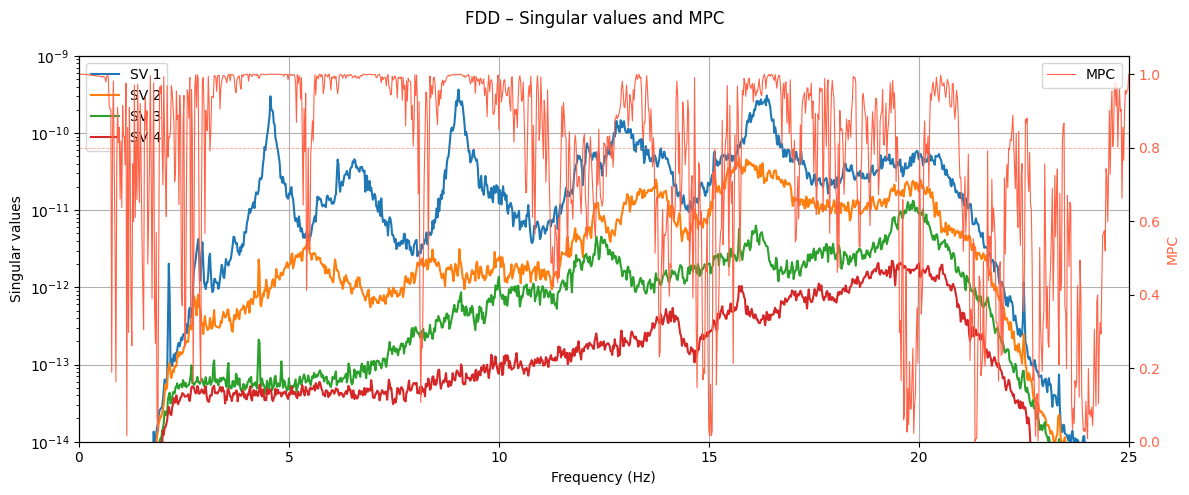

In [8]:
# Modal Assurance Criterion
# MAC(a, b) = |aᴴ b|² / [(aᴴ a)(bᴴ b)] ∈ [0, 1]
def mac(a, b):
    return np.abs(a.conj().T @ b)**2 / ((a.conj().T @ a) * (b.conj().T @ b)).real

# Modal Phase Collinearity (MPC): MAC between a mode φ and its complex conjugate φ*
# MPC(φ) = MAC(φ, φ*) = |φᵀ φ|² / (φᴴ φ)²  ∈ [0, 1]
# We estimate MPC at each discrete frequency
MPC = np.zeros(nf)
for k in range(nf):
    phi = U1[:, k]
    MPC[k] = mac(phi,phi.conj()) # MAC between φ and φ*

# Plot all SVs + MPC
fig, ax1 = plt.subplots(figsize=(12, 5))

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
for i in range(N):
    ax1.semilogy(fv, S_all[i, :], label=f'SV {i+1}', color=colors[i])
ax1.set_xlabel('Frequency (Hz)')
ax1.set_ylabel('Singular values')
ax1.set_xlim(0, fs_dec / 2)
ax1.set_ylim(1e-14, 1e-9)
ax1.grid(True)
ax1.legend(loc='upper left', frameon=True)

ax2 = ax1.twinx()
ax2.plot(fv, MPC, color='tomato', linewidth=0.8, label='MPC')
ax2.axhline(0.8, color='tomato', linestyle='--', linewidth=0.6, alpha=0.6)
ax2.set_ylabel('MPC', color='tomato')
ax2.tick_params(axis='y', labelcolor='tomato')
ax2.set_ylim(0, 1.05)
ax2.legend(loc='upper right')

fig.suptitle('FDD – Singular values and MPC')
fig.tight_layout()
plt.show()


### Modal identification - peak picking of SV

We can now proceed with **modal identification** by "picking" amplifications peaks on the first singular value with high MPC (typically >0.8) and extracting the corresponding mode shapes. The task can be easily automated using MPC as an acceptance criterion!

Selected peaks:
  f = 4.560 Hz  |  SV1 = 2.990e-10  |  MPC = 1.000
  f = 6.540 Hz  |  SV1 = 4.135e-11  |  MPC = 0.993
  f = 9.040 Hz  |  SV1 = 3.649e-10  |  MPC = 1.000
  f = 12.900 Hz  |  SV1 = 1.466e-10  |  MPC = 0.919
  f = 13.900 Hz  |  SV1 = 4.717e-11  |  MPC = 0.631
  f = 16.360 Hz  |  SV1 = 2.287e-10  |  MPC = 0.961


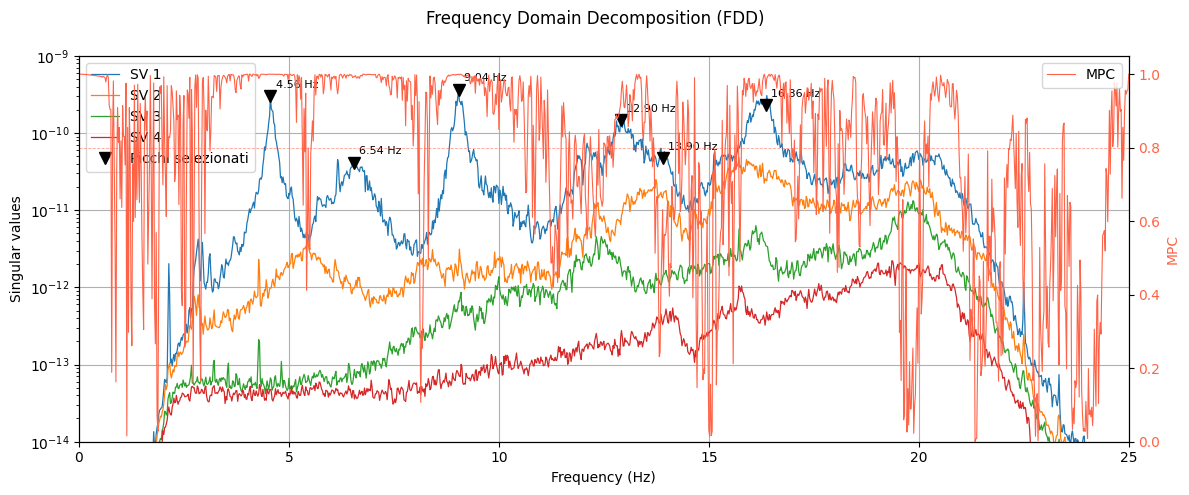

In [9]:
import pandas as pd

# Frequency peaks with high MPC (except one!)
f_sel = [4.56, 6.55, 9.05, 12.90, 13.90, 16.35]
#f_sel = [4.56, 6.55, 12.90, 13.90] after cross-MAC analysis

# Closest freq bin
peaks_sel = [np.argmin(np.abs(fv - f)) for f in f_sel]

print("Selected peaks:")
for k in peaks_sel:
    print(f"  f = {fv[k]:.3f} Hz  |  SV1 = {S_all[0, k]:.3e}  |  MPC = {MPC[k]:.3f}")

# SV + selected peaks
fig, ax1 = plt.subplots(figsize=(12, 5))
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
for i in range(N):
    ax1.semilogy(fv, S_all[i, :], label=f'SV {i+1}', lw=0.9, color=colors[i])
ax1.semilogy(fv[peaks_sel], S_all[0, peaks_sel], 'kv', ms=8, label='Picchi selezionati')
for k in peaks_sel:
    ax1.annotate(f'{fv[k]:.2f} Hz', xy=(fv[k], S_all[0, k]),
                 xytext=(4, 6), textcoords='offset points', fontsize=8)
ax1.set_xlabel('Frequency (Hz)')
ax1.set_ylabel('Singular values')
ax1.set_xlim(0, fs_dec / 2)
ax1.set_ylim(1e-14, 1e-9)
ax1.grid(True)
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
ax2.plot(fv, MPC, color='tomato', lw=0.8, label='MPC')
ax2.axhline(0.8, color='tomato', ls='--', lw=0.6, alpha=0.6)
ax2.set_ylabel('MPC', color='tomato')
ax2.tick_params(axis='y', labelcolor='tomato')
ax2.set_ylim(0, 1.05)
ax2.legend(loc='upper right')
fig.suptitle('Frequency Domain Decomposition (FDD)')
fig.tight_layout()
plt.show()

As a double quality check we can plot the mode shapes real and complex components on the complex plane to verify their actual collinearity --- "real" or collinear modes with high MPC should lie on a straight line.

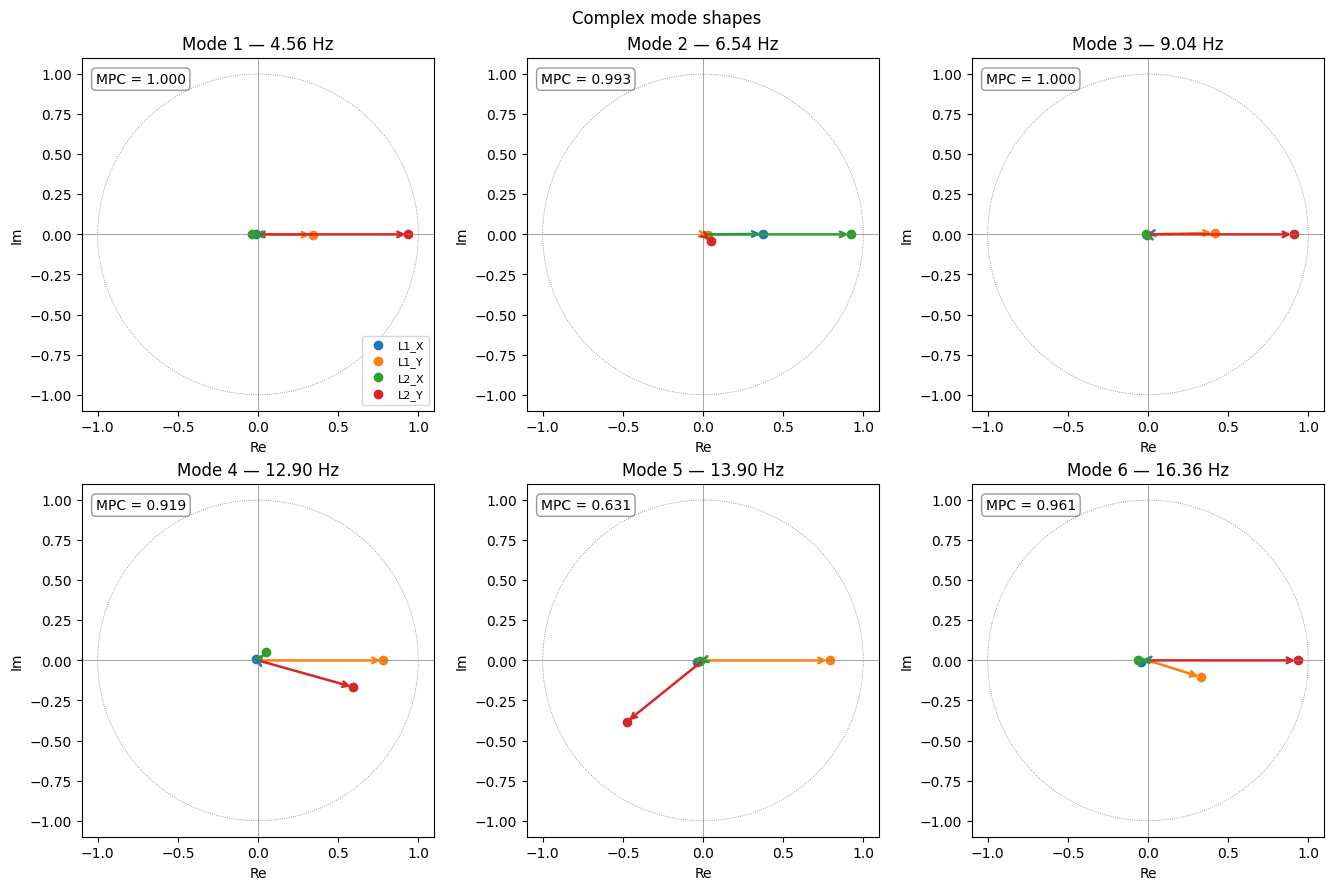

In [10]:
n_modes = len(peaks_sel)

# Normalize complex mode shapes - we rotate the dominant comp. to +Re and keep unit norm
phi_un = []
for k in peaks_sel:
    phi = U1[:, k].copy()
    phi = phi / phi[np.argmax(np.abs(phi))]   # real positive (+1)
    phi = phi / np.linalg.norm(phi)           # unit norm
    phi_un.append(phi)

# Complex plane plot
nrows = 2
ncols = int(np.ceil(n_modes / nrows))
fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 4.5 * nrows),
                         subplot_kw={'aspect': 'equal'})
axes = np.atleast_1d(axes).ravel()

for m, (k, phi) in enumerate(zip(peaks_sel, phi_un)):
    ax = axes[m]
    for i in range(N):
        ax.annotate('', xy=(phi[i].real, phi[i].imag), xytext=(0, 0),
                    arrowprops=dict(arrowstyle='->', color=colors[i], lw=1.8))
        ax.plot(phi[i].real, phi[i].imag, 'o', color=colors[i], label=channel_names[i])
    lim = 1.1
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
    circle = plt.Circle((0, 0), 1.0, color='gray', ls=':', fill=False, lw=0.6)
    ax.add_patch(circle)
    ax.set_xlabel('Re'); ax.set_ylabel('Im')
    ax.set_title(f'Mode {m+1} — {fv[k]:.2f} Hz')
    # MPC overlay
    ax.text(0.04, 0.96, f'MPC = {MPC[k]:.3f}', transform=ax.transAxes,
            va='top', ha='left', fontsize=10,
            bbox=dict(boxstyle='round', fc='white', ec='gray', alpha=0.8))
    if m == 0:
        ax.legend(loc='lower right', fontsize=8)

# hide any unused axes
for ax in axes[n_modes:]:
    ax.axis('off')

fig.suptitle('Complex mode shapes')
fig.tight_layout()
plt.show()

### Mode shapes normalization

 Now we extract the **complex mode shapes** and turn them **real**.
 We have two alternatives, both first apply a global phase rotation so the dominant component is real (+1), then either:

- **project** the vector on the real axis, i.e. keep only the real part -> phi_norm = Re(phi)
- **rotate** the vector on the real axis, keeping his modulus and original sign -> phi_norm = |phi| * sign(Re(phi))

For a perfectly collinear mode the two coincide. The first approach is acceptable for real modes (MPC ≈ 1). The second approach preserves the full amplitude when the mode is slightly complex (MPC << 1).

In [11]:
# Extract real mode shapes and plot summary table
phi_nr = []
rows = []
for mode_num, k in enumerate(peaks_sel, start=1):
    phi = U1[:, k]
    phi_norm = phi / phi[np.argmax(np.abs(phi))]                    # global phase rotation: dominant -> +Re
    #phi_norm_real = np.real(phi_norm)                              # approach 1 -> real part
    phi_norm_real = np.abs(phi_norm) * np.sign(np.real(phi_norm))   # approach 2 -> rotation
    phi_nr.append(phi_norm_real)
    row = {'Mode': mode_num, 'Frequency (Hz)': round(fv[k], 3), 'MPC': round(MPC[k], 3)}
    for i, ch in enumerate(channel_names):
        row[ch] = round(phi_norm_real[i], 4)
    rows.append(row)

df_modes = pd.DataFrame(rows).set_index('Mode')
print("\nOutput-only modal identification by FDD - summary")
display(df_modes)



Output-only modal identification by FDD - summary


,Frequency (Hz),MPC,L1_X,L1_Y,L2_X,L2_Y
Mode,,,,,,
1,4.56,1.000,-0.0113,0.3657,-0.0411,1.0000
2,6.54,0.993,0.4069,0.0315,1.0000,0.0723
3,9.04,1.000,-0.0074,0.4563,-0.0144,1.0000
4,12.90,0.919,-0.0219,1.0000,0.0917,0.7907
5,13.90,0.631,-0.0507,1.0000,-0.0245,-0.7748
6,16.36,0.961,-0.0468,0.3712,-0.0648,1.0000


### Post-identification checks: spatial aliasing

To verify the set of modes is not affected by **spatial aliasing**, i.e. each mode shape is clearly distinguishable from the others, we can compute the **cross-MAC matrix**.

In the ideal case we should find an identity matrix. Practically this never happens and we should expect, for a well-behaved identification, a quasi-diagonal matrix with unit values on the diagonal — MAC(φi,φi)=1 — and close-to-zero values out of it — MAC(φi,φj)≈0.

The presence of non-zero out-of-diagonal values is related to the impossibility of employing enough sensors to capture the complex shape of high-frequency or high-order modes.

Cross-MAC matrix


,Mode 1,Mode 2,Mode 3,Mode 4,Mode 5,Mode 6
Mode 1,1.000,0.001,0.993,0.716,0.091,0.998
Mode 2,0.001,1.000,0.003,0.015,0.003,0.000
Mode 3,0.993,0.003,1.000,0.786,0.052,0.991
Mode 4,0.716,0.015,0.786,1.000,0.057,0.716
Mode 5,0.091,0.003,0.052,0.057,1.000,0.087
Mode 6,0.998,0.000,0.991,0.716,0.087,1.000


/tmp/ipykernel_8493/2399836220.py:46: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


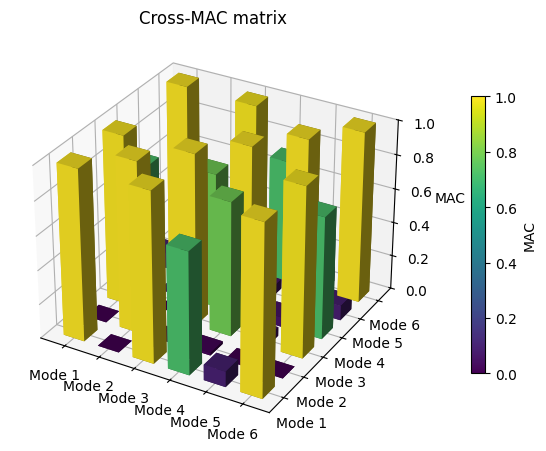

In [12]:
from mpl_toolkits.mplot3d import Axes3D  # for plotting
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

# Cross-MAC matrix
cross_mac = np.zeros((n_modes, n_modes))
for a in range(n_modes):
    for b in range(n_modes):
        cross_mac[a, b] = mac(phi_nr[a], phi_nr[b])

print("Cross-MAC matrix")
display(pd.DataFrame(np.round(cross_mac, 3),
                     index=[f'Mode {i+1}' for i in range(n_modes)],
                     columns=[f'Mode {i+1}' for i in range(n_modes)]))

# 3D bar chart
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection='3d')

xpos, ypos = np.meshgrid(np.arange(n_modes), np.arange(n_modes), indexing='ij')
xpos = xpos.ravel(); ypos = ypos.ravel()
zpos = np.zeros_like(xpos, dtype=float)
dx = dy = 0.6
dz = cross_mac.ravel()

# Color bars by MAC value
cmap = plt.cm.viridis
norm = Normalize(vmin=0, vmax=1)
bar_colors = cmap(norm(dz))
ax.bar3d(xpos, ypos, zpos, dx, dy, dz, color=bar_colors, shade=True)

ax.set_xticks(np.arange(n_modes) + dx / 2)
ax.set_yticks(np.arange(n_modes) + dy / 2)
ax.set_xticklabels([f'Mode {i+1}' for i in range(n_modes)])
ax.set_yticklabels([f'Mode {i+1}' for i in range(n_modes)])
ax.set_zlim(0, 1)
ax.set_zlabel('MAC')
ax.set_title('Cross-MAC matrix')

# Color legend (colorbar)
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, shrink=0.6, pad=0.1)
cbar.set_label('MAC')

plt.tight_layout()
plt.show()


Mode 3 and mode 6 are very similar to each other and practically indistinguishable from mode 1 — see MAC(φ1,φ3) and MAC(φ1,φ6), both very close to 1! Mode 4 is also quite similar to mode 1 (MAC(φ1,φ4)≈0.6).

## Estimation of modal damping ratios

Two approaches:
1. **Half-power bandwidth**: direct measurement of the −3 dB bandwidth (half-power) around the resonance peak on the singular value spectrum. Simple and fast but affected by neighboring close-modes.
2. **Enhanced FDD (EFDD)**: isolates the SDOF bell via MAC threshold (modal domain), goes back to the time domain via inverse FTT and fits the free decay envelope of the autocorrelation function with log-decrement. More robust but computationally more involved.

Both are very sensitive to frequency resolution!

### Half-power bandwidth method

See: https://www.vibrationdata.com/tutorials2/half_power_bandwidth.pdf

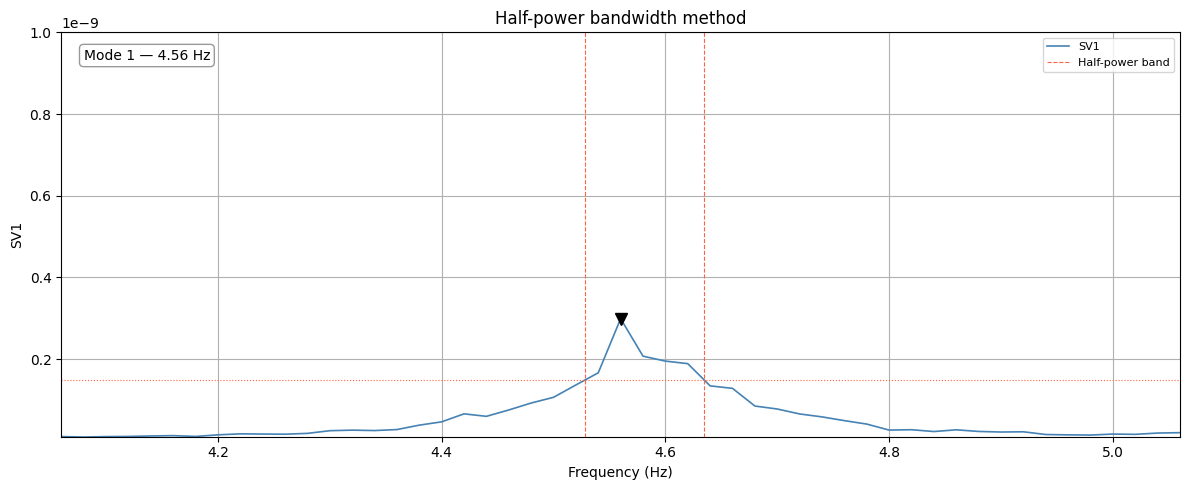

Mode 1 — half-power bandwith method:
  f_n = 4.560 Hz
  f_d = 4.560 Hz
  f1 = 4.529 Hz  |  f2 = 4.634 Hz
  ζ = 0.0116 (1.161%)


In [13]:
from scipy.signal import find_peaks

# Half-power bandwidth method on SV
k1 = peaks_sel[0]          # selected mode
fn = fv[k1]                # natural frequency (Hz)
phi_ref = U1[:, k1]        # reference mode shape (at the peak)

# Find half-power with respect to the peak
Sp   = S_all[0, k1]
half = Sp / 2.0

# Estimate the bandwith
# left crossing (interpolated)
li = k1
while li > 0 and S_all[0, li] > half:
    li -= 1
f1 = np.interp(half, [S_all[0, li], S_all[0, li + 1]], [fv[li], fv[li + 1]])

# right crossing (interpolated)
ri = k1
while ri < nf - 1 and S_all[0, ri] > half:
    ri += 1
f2 = np.interp(half, [S_all[0, ri], S_all[0, ri - 1]], [fv[ri], fv[ri - 1]])

# Half-power bandwith
zeta_hp = (f2 - f1) / (2.0 * fn) # damping ratio
fd_hp = fn * np.sqrt(1 - zeta_hp**2) # damped frequency

# Plot half-power band
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(fv, S_all[0, :], color='steelblue', lw=1.2, label='SV1')
ax.axvline(f1, color='tomato', ls='--', lw=0.8, label='Half-power band')
ax.axvline(f2, color='tomato', ls='--', lw=0.8)
ax.axhline(half, color='tomato', ls=':', lw=0.8)
ax.plot(fn, Sp, 'kv', ms=8)
ax.set_xlim(max(0, fn - 0.5), fn + 0.5)
ax.set_ylim(10e-12, 1e-9)
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('SV1')
ax.set_title(f'Half-power bandwidth method')
# Mode overlay
ax.text(0.02, 0.96, f'Mode 1 — {fn:.2f} Hz', transform=ax.transAxes,
            va='top', ha='left', fontsize=10,
            bbox=dict(boxstyle='round', fc='white', ec='gray', alpha=0.8))
ax.legend(fontsize=8)
ax.grid(True)
fig.tight_layout()
plt.show()

print(f"Mode 1 — half-power bandwith method:")
print(f"  f_n = {fn:.3f} Hz")
print(f"  f_d = {fd_hp:.3f} Hz")
print(f"  f1 = {f1:.3f} Hz  |  f2 = {f2:.3f} Hz")
print(f"  ζ = {zeta_hp:.4f} ({zeta_hp*100:.3f}%)")

### Enhanced FDD (EFDD)

See: Brincker, R., Ventura, C. E., & Andersen, P. (2001, February). Damping estimation by frequency domain decomposition. In 19th International Modal Analysis Conference (Vol. 9, pp. 698-703).
https://vbn.aau.dk/ws/portalfiles/portal/12773740/Damping_Estimation_by_Frequency_Domain_Decomposition

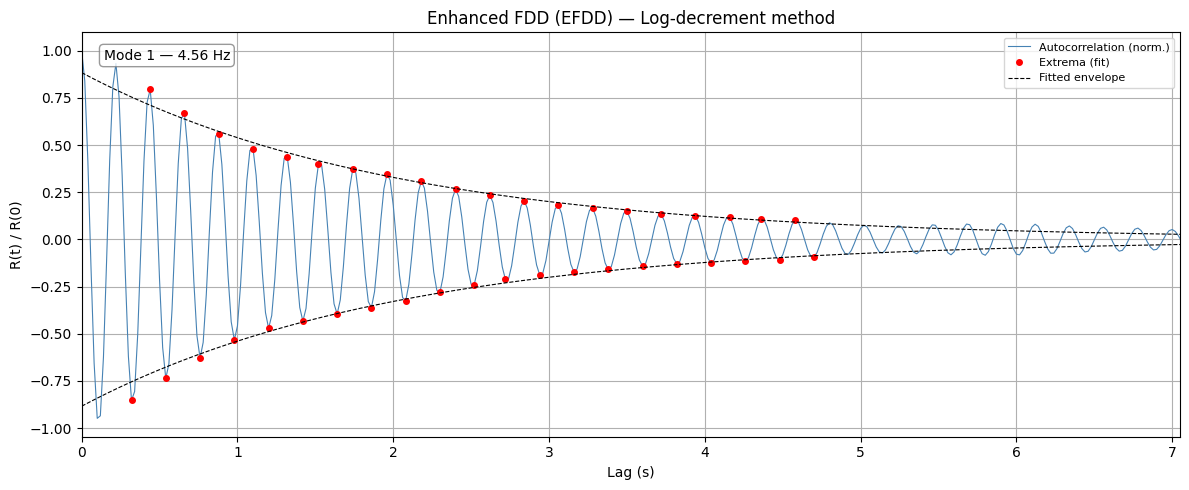

Mode 1 — Enhanced FDD (log-decrement method):
  f_n = 4.560 Hz
  f_d = 4.559 Hz
  MAC threshold = 0.9
  Modal domain = 3.02 – 5.30 Hz
  ζ = 0.0173 (1.726%)


In [14]:
# Enhanced FDD (EFDD): SDOF bell from MAC domain + log-decrement
# Set MAC threshold for the SDOF modal domain
mac_thr = 0.9
mac_vals = np.array([mac(phi_ref, U1[:, k]) for k in range(nf)])

lo = k1
while lo > 0 and mac_vals[lo - 1] >= mac_thr:
    lo -= 1
hi = k1
while hi < nf - 1 and mac_vals[hi + 1] >= mac_thr:
    hi += 1
bell_idx = np.arange(lo, hi + 1)
f_lo, f_hi = fv[lo], fv[hi]

# Isolate the SDOF bell on the one-sided SV spectrum
S_bell = np.zeros(nf)
S_bell[bell_idx] = S_all[0, bell_idx]

# Invert to time domain to get the autocorrelation function
Nfft = 2 * (nf - 1)
two_sided = np.zeros(Nfft)
two_sided[:nf] = S_bell
two_sided[nf:] = S_bell[nf - 2:0:-1]   # even-symmetric

R = np.fft.ifft(two_sided).real        # inverse FFT
R = R[:Nfft // 2]                      # positive lags
R = R / R[0]                           # normalize R(0)=1
tau = np.arange(len(R)) / fs_dec       # lag time (s)

# Log-decrement fit on autocorrelation extrema
absR = np.abs(R)
ext, _ = find_peaks(absR)              # extrema (peaks & troughs)
# fit window: between 90% and 10% of first extremum
A0 = absR[ext[0]]
sel = ext[(absR[ext] <= 0.9 * A0) & (absR[ext] >= 0.1 * A0)]

slope, intercept = np.polyfit(tau[sel], np.log(absR[sel]), 1)
wn = 2.0 * np.pi * fn
zeta_log = -slope / wn                 # envelope decays as exp(-zeta*wn*tau)
delta = 2.0 * np.pi * zeta_log / np.sqrt(1.0 - zeta_log**2)   # log decrement
fd_log = fn * np.sqrt(1 - zeta_log**2) # damped frequency

# Plot autocorrelation with fitted envelope
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(tau, R, color='steelblue', lw=0.8, label='Autocorrelation (norm.)')
ax.plot(tau[sel], R[sel], 'r.', ms=8, label='Extrema (fit)')
ax.plot(tau, np.exp(intercept + slope * tau), 'k--', lw=0.8, label='Fitted envelope')
ax.plot(tau, -np.exp(intercept + slope * tau), 'k--', lw=0.8)
ax.set_xlim(0, tau[sel[-1]] * 1.5 if len(sel) else tau[-1])
ax.set_xlabel('Lag (s)')
ax.set_ylabel('R(t) / R(0)')
ax.set_title('Enhanced FDD (EFDD) — Log-decrement method')
# Mode overlay
ax.text(0.02, 0.96, f'Mode 1 — {fn:.2f} Hz', transform=ax.transAxes,
            va='top', ha='left', fontsize=10,
            bbox=dict(boxstyle='round', fc='white', ec='gray', alpha=0.8))
ax.legend(fontsize=8)
ax.grid(True)
fig.tight_layout()
plt.show()

print(f"Mode 1 — Enhanced FDD (log-decrement method):")
print(f"  f_n = {fn:.3f} Hz")
print(f"  f_d = {fd_log:.3f} Hz")
print(f"  MAC threshold = {mac_thr}")
print(f"  Modal domain = {f_lo:.2f} – {f_hi:.2f} Hz")
print(f"  ζ = {zeta_log:.4f} ({zeta_log*100:.3f}%)")